# Ejecución presupuestal - Proyectos por gobiernos regionales - Provinciales - Distritales - Mes de julio 2026

### Objetivo

- Determinar que gobiernos regionales del Perú esta ejecutando mejor su presupuesto de proyectos a la fecha de julio 2026.
- Analizar que provincias de la región junín esta ejecutando mejor su presupuesto de proyectos a la fecha de julio 2026.
- Analizar que distritos de la Provincia de Huancayo esta ejecutando mejor su presupuesto de proyectos a la fecha de julio 2026.

### Fuente de datos

- [Presupuesto publico 2026](https://datosabiertos.mef.gob.pe/dataset/presupuesto-y-ejecucion-de-gasto)

In [2]:
# Librearias
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# plt.style.use('')
plt.rcParams.update({
    'figure.figsize'    :   (12,6)      ,
    # 'axes.facecolor'    :   '#0d1117'   ,
    # 'figure.facecolor'  :   '#30363d'   ,
    'grid.linestyle'    :   '--'        ,
    'grid.alpha'        :   0.5         ,
    'font.size'         :   10          ,
})

In [3]:
df = pd.read_csv('../data/raw/2026-Gasto-Mensual.csv',
                dtype = {
                    'SECTOR'        :   'string',
                    'PLIEGO'        :   'string',
                    'TIPO_RECURSO'  :   'string'
                })
df.head(2)

,ANO_EJE,MES_EJE,NIVEL_GOBIERNO,NIVEL_GOBIERNO_NOMBRE,SECTOR,SECTOR_NOMBRE,PLIEGO,PLIEGO_NOMBRE,SEC_EJEC,EJECUTORA,...,ESPECIFICA_NOMBRE,ESPECIFICA_DET,ESPECIFICA_DET_NOMBRE,MONTO_PIA,MONTO_PIM,MONTO_CERTIFICADO,MONTO_COMPROMETIDO_ANUAL,MONTO_COMPROMETIDO,MONTO_DEVENGADO,MONTO_GIRADO
0,2026,7,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL DEL DEPARTAMENTO DE AMAZONAS,723,200,...,VIAJES DOMESTICOS,2,VIATICOS Y ASIGNACIONES POR COMISION DE SERVICIO,0,0,75.0,75.0,75.0,75.0,75.0
1,2026,7,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL DEL DEPARTAMENTO DE AMAZONAS,723,200,...,"DE CARRETERAS, CAMINOS Y PUENTES NO CONCESION...",1,"DE CARRETERAS, CAMINOS Y PUENTES NO CONCESION...",0,0,0.0,0.0,0.0,77403.2,77403.2


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 6836564 entries, 0 to 6836563
Data columns (total 63 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   ANO_EJE                        int64  
 1   MES_EJE                        int64  
 2   NIVEL_GOBIERNO                 str    
 3   NIVEL_GOBIERNO_NOMBRE          str    
 4   SECTOR                         string 
 5   SECTOR_NOMBRE                  str    
 6   PLIEGO                         string 
 7   PLIEGO_NOMBRE                  str    
 8   SEC_EJEC                       int64  
 9   EJECUTORA                      int64  
 10  EJECUTORA_NOMBRE               str    
 11  DEPARTAMENTO_EJECUTORA         int64  
 12  DEPARTAMENTO_EJECUTORA_NOMBRE  str    
 13  PROVINCIA_EJECUTORA            int64  
 14  PROVINCIA_EJECUTORA_NOMBRE     str    
 15  DISTRITO_EJECUTORA             int64  
 16  DISTRITO_EJECUTORA_NOMBRE      str    
 17  SEC_FUNC                       int64  
 18  PROGRAMA_PPTO

In [4]:
print(df.isnull().sum())

ANO_EJE                     0
MES_EJE                     0
NIVEL_GOBIERNO              0
NIVEL_GOBIERNO_NOMBRE       0
SECTOR                      0
                           ..
MONTO_CERTIFICADO           0
MONTO_COMPROMETIDO_ANUAL    0
MONTO_COMPROMETIDO          0
MONTO_DEVENGADO             0
MONTO_GIRADO                0
Length: 63, dtype: int64


In [5]:
# COMPRENSIÓN DE LAS VARIABLES

# print(df.NIVEL_GOBIERNO_NOMBRE.unique())
# print(df.SEC_EJEC.unique())
# print(df.EJECUTORA.unique())
# print(df.EJECUTORA_NOMBRE.unique())
# print(df.DEPARTAMENTO_EJECUTORA_NOMBRE.unique())
# print(df.PROVINCIA_EJECUTORA_NOMBRE.unique())
# print(df.DISTRITO_EJECUTORA_NOMBRE.unique())
# print(df.PROGRAMA_PPTO_NOMBRE.unique())
# print(df.TIPO_ACT_PROY_NOMBRE.unique())
# print(df.PRODUCTO_PROYECTO_NOMBRE.unique())
# print(df.GENERICA_NOMBRE.unique())
# print(df.SUBGENERICA_NOMBRE.unique())
# print(df.ESPECIFICA_NOMBRE.unique())
# print(df.FUNCION_NOMBRE.unique())
# print(df.PROGRAMA_PPTO_NOMBRE.unique())
# print(df.CATEGORIA_GASTO_NOMBRE.unique())
# print(df.TIPO_ACT_PROY_NOMBRE.unique())
# print(df.GENERICA_NOMBRE.unique())


In [6]:
df[['MONTO_PIA', 'MONTO_PIM', 'MONTO_CERTIFICADO', 'MONTO_COMPROMETIDO_ANUAL', 'MONTO_COMPROMETIDO', 'MONTO_DEVENGADO', 'MONTO_GIRADO']].describe()

,MONTO_PIA,MONTO_PIM,MONTO_CERTIFICADO,MONTO_COMPROMETIDO_ANUAL,MONTO_COMPROMETIDO,MONTO_DEVENGADO,MONTO_GIRADO
count,6.836564e+06,6.836564e+06,6.836564e+06,6.836564e+06,6.836564e+06,6.836564e+06,6.836564e+06
mean,3.767413e+04,4.135564e+04,3.571061e+04,3.249138e+04,2.465207e+04,2.139200e+04,2.086575e+04
std,5.459461e+06,5.353106e+06,5.310554e+06,5.294040e+06,3.511308e+06,2.557122e+06,2.512006e+06
min,0.000000e+00,-1.165660e+05,-1.140409e+09,-1.000462e+09,0.000000e+00,-8.937874e+07,-1.588818e+09
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00,6.452850e+02,8.025000e+02,2.266832e+03,2.182747e+03,2.000000e+03
max,1.078797e+10,1.078797e+10,1.078790e+10,1.078790e+10,6.221093e+09,4.237755e+09,4.237755e+09


In [7]:
df[df['MONTO_PIM'] == -1.165660e+05]

,ANO_EJE,MES_EJE,NIVEL_GOBIERNO,NIVEL_GOBIERNO_NOMBRE,SECTOR,SECTOR_NOMBRE,PLIEGO,PLIEGO_NOMBRE,SEC_EJEC,EJECUTORA,...,ESPECIFICA_NOMBRE,ESPECIFICA_DET,ESPECIFICA_DET_NOMBRE,MONTO_PIA,MONTO_PIM,MONTO_CERTIFICADO,MONTO_COMPROMETIDO_ANUAL,MONTO_COMPROMETIDO,MONTO_DEVENGADO,MONTO_GIRADO
4369415,2026,0,M,GOBIERNOS LOCALES,,,,,300041,10402,...,SERVICIOS DE CONSULTORIAS Y SIMILARES DESARROL...,99,OTROS SERVICIOS SIMILARES,3500,-116566,0.0,0.0,0.0,0.0,0.0


In [8]:
df[df["MES_EJE"] == 0][
    ["MONTO_PIA", "MONTO_PIM", "MONTO_DEVENGADO"]
].describe()

,MONTO_PIA,MONTO_PIM,MONTO_DEVENGADO
count,1.629036e+06,1.629036e+06,1629036.0
mean,1.581068e+05,1.735569e+05,0.0
std,1.118331e+07,1.096524e+07,0.0
min,0.000000e+00,-1.165660e+05,0.0
25%,0.000000e+00,6.000000e+02,0.0
50%,1.000000e+03,4.200000e+03,0.0
75%,1.151900e+04,2.726400e+04,0.0
max,1.078797e+10,1.078797e+10,0.0


In [9]:
df[df["MES_EJE"] == 0]["NIVEL_GOBIERNO_NOMBRE"].value_counts()

NIVEL_GOBIERNO_NOMBRE
GOBIERNOS LOCALES       881123
GOBIERNOS REGIONALES    389782
GOBIERNO NACIONAL       358131
Name: count, dtype: int64

In [10]:
df['NIVEL_GOBIERNO_NOMBRE'].value_counts()

NIVEL_GOBIERNO_NOMBRE
GOBIERNOS LOCALES       3636486
GOBIERNOS REGIONALES    1603748
GOBIERNO NACIONAL       1596330
Name: count, dtype: int64

In [11]:
df['TIPO_ACT_PROY_NOMBRE'].value_counts(dropna=False)

TIPO_ACT_PROY_NOMBRE
ACTIVIDAD    6136418
PROYECTO      700146
Name: count, dtype: int64

Filtramos por GOBIERNOS LOCALES, PROYECTO Y GASTO CAPITAL, para identificar las inversiones públicas.

In [12]:
proyectos_locales = df[(df['NIVEL_GOBIERNO_NOMBRE'] == 'GOBIERNOS LOCALES') &
                (df['TIPO_ACT_PROY_NOMBRE'] == 'PROYECTO') & 
                (df['CATEGORIA_GASTO_NOMBRE'] == 'GASTO DE CAPITAL')]

In [13]:
num_proyectos = (proyectos_locales
                .groupby(['DEPARTAMENTO_EJECUTORA_NOMBRE','PROVINCIA_EJECUTORA_NOMBRE', 'FUNCION_NOMBRE'])['PRODUCTO_PROYECTO']
                .nunique()
                .reset_index()
                .sort_values(by=['DEPARTAMENTO_EJECUTORA_NOMBRE','PRODUCTO_PROYECTO'], ascending=False))


num_proyectos[num_proyectos['PROVINCIA_EJECUTORA_NOMBRE'] == 'HUANCAYO']

,DEPARTAMENTO_EJECUTORA_NOMBRE,PROVINCIA_EJECUTORA_NOMBRE,FUNCION_NOMBRE,PRODUCTO_PROYECTO
1376,JUNIN,HUANCAYO,TRANSPORTE,183
1375,JUNIN,HUANCAYO,SANEAMIENTO,101
1369,JUNIN,HUANCAYO,CULTURA Y DEPORTE,37
1372,JUNIN,HUANCAYO,"PLANEAMIENTO, GESTION Y RESERVA DE CONTINGENCIA",35
1378,JUNIN,HUANCAYO,VIVIENDA Y DESARROLLO URBANO,34
1370,JUNIN,HUANCAYO,EDUCACION,33
1367,JUNIN,HUANCAYO,AGROPECUARIA,16
1374,JUNIN,HUANCAYO,SALUD,16
1368,JUNIN,HUANCAYO,AMBIENTE,11
1371,JUNIN,HUANCAYO,ORDEN PUBLICO Y SEGURIDAD,9


In [14]:
proyectos_locales.groupby('FUNCION_NOMBRE')['PRODUCTO_PROYECTO'].nunique().sort_values(ascending=False)

FUNCION_NOMBRE
TRANSPORTE                                         10702
SANEAMIENTO                                         5274
CULTURA Y DEPORTE                                   5224
AGROPECUARIA                                        4205
EDUCACION                                           4098
PLANEAMIENTO, GESTION Y RESERVA DE CONTINGENCIA     3802
VIVIENDA Y DESARROLLO URBANO                        3030
ORDEN PUBLICO Y SEGURIDAD                           1094
AMBIENTE                                             994
SALUD                                                927
ENERGIA                                              639
PROTECCION SOCIAL                                    507
TURISMO                                              374
COMERCIO                                             291
INDUSTRIA                                            275
COMUNICACIONES                                        79
PESCA                                                 40
TRABAJO         

### Porcentaje de ejecución de proyectos publicos de la provicina de Huancayo y sus distritos


In [ ]:
# PROYECTOS HUANCAYO PROVICIA Y SUS DISTRITOS MUNICIPALES
hyo_provincia = (proyectos_locales
        .groupby(['DEPARTAMENTO_EJECUTORA_NOMBRE','PROVINCIA_EJECUTORA_NOMBRE', 'EJECUTORA_NOMBRE'])
                [['MONTO_PIA','MONTO_PIM', 'MONTO_DEVENGADO']]
        .sum()
        .reset_index()
        .sort_values('MONTO_PIM', ascending=False))

hyo_provincia['EJECUCION_%'] = (hyo_provincia['MONTO_DEVENGADO'] / hyo_provincia['MONTO_PIM'])  * 100

hyo_provincia = (hyo_provincia[(hyo_provincia['DEPARTAMENTO_EJECUTORA_NOMBRE'] == 'JUNIN') & 
                (hyo_provincia['PROVINCIA_EJECUTORA_NOMBRE'] == 'HUANCAYO')]
                .sort_values('EJECUCION_%', ascending=False))

hyo_provincia.to_csv('hyo_provincia.csv', index=False)

hyo_provincia

,DEPARTAMENTO_EJECUTORA_NOMBRE,PROVINCIA_EJECUTORA_NOMBRE,EJECUTORA_NOMBRE,MONTO_PIA,MONTO_PIM,MONTO_DEVENGADO,EJECUCION_%
1077,JUNIN,HUANCAYO,MUNICIPALIDAD DISTRITAL DE COLCA,998679,1195230,1070079.36,89.529158
1088,JUNIN,HUANCAYO,MUNICIPALIDAD DISTRITAL DE PUCARA,1571933,6436887,4274750.70,66.410218
1071,JUNIN,HUANCAYO,MUNICIPALIDAD DISTRITAL DE CARHUACALLANGA,593885,2504679,1476371.36,58.944534
1075,JUNIN,HUANCAYO,MUNICIPALIDAD DISTRITAL DE CHONGOS ALTO,556732,6383517,3173967.99,49.721306
1093,JUNIN,HUANCAYO,MUNICIPALIDAD DISTRITAL DE SANTO DOMINGO DE AC...,2741459,6042623,2991596.47,49.508243
1090,JUNIN,HUANCAYO,MUNICIPALIDAD DISTRITAL DE QUILCAS,393492,4110758,1930339.43,46.958236
1094,JUNIN,HUANCAYO,MUNICIPALIDAD DISTRITAL DE SAPALLANGA,2637496,12709486,4937756.59,38.850954
1084,JUNIN,HUANCAYO,MUNICIPALIDAD DISTRITAL DE HUAYUCACHI,11262017,17807841,6872378.63,38.591869
1085,JUNIN,HUANCAYO,MUNICIPALIDAD DISTRITAL DE INGENIO,1271998,2892513,1091346.00,37.730029
1079,JUNIN,HUANCAYO,MUNICIPALIDAD DISTRITAL DE EL TAMBO,9918676,30186711,10966583.89,36.329178


In [45]:
m6 = proyectos_hyo[proyectos_hyo['MES_EJE'] <= 6].groupby(['EJECUTORA_NOMBRE'])[['MONTO_PIA','MONTO_PIM','MONTO_DEVENGADO']].sum().reset_index()
m6['EJECUCION_%_6'] = (m6['MONTO_DEVENGADO'] / m6['MONTO_PIM'])  * 100

m7 = proyectos_hyo[proyectos_hyo['MES_EJE'] <= 7].groupby(['EJECUTORA_NOMBRE'])[['MONTO_PIA','MONTO_PIM','MONTO_DEVENGADO']].sum().reset_index()
m7['EJECUCION_%_7'] = (m7['MONTO_DEVENGADO'] / m7['MONTO_PIM'])  * 100

variacion_hyo = m6.merge(m7, on=['EJECUTORA_NOMBRE', 'MONTO_PIA', 'MONTO_PIM'], how='left')
variacion_hyo

,EJECUTORA_NOMBRE,MONTO_PIA,MONTO_PIM,MONTO_DEVENGADO_x,EJECUCION_%_6,MONTO_DEVENGADO_y,EJECUCION_%_7
0,MUNICIPALIDAD DISTRITAL DE CARHUACALLANGA,593885,2504679,356639.70,14.238938,1476371.36,58.944534
1,MUNICIPALIDAD DISTRITAL DE CHACAPAMPA,109035,1314382,271622.99,20.665453,314030.87,23.891903
2,MUNICIPALIDAD DISTRITAL DE CHICCHE,22318,446734,61779.60,13.829169,99833.60,22.347437
3,MUNICIPALIDAD DISTRITAL DE CHILCA,3599168,30089230,5535810.30,18.397979,6527893.79,21.695117
4,MUNICIPALIDAD DISTRITAL DE CHONGOS ALTO,556732,6383517,2058104.42,32.240917,3173967.99,49.721306
5,MUNICIPALIDAD DISTRITAL DE CHUPURO,205877,2397281,42300.00,1.764499,331491.59,13.827815
6,MUNICIPALIDAD DISTRITAL DE COLCA,998679,1195230,1068864.36,89.427504,1070079.36,89.529158
7,MUNICIPALIDAD DISTRITAL DE CULLHUAS,101239,792021,112446.06,14.197358,259441.67,32.756918
8,MUNICIPALIDAD DISTRITAL DE EL TAMBO,9918676,30186711,8466615.54,28.047493,10966583.89,36.329178
9,MUNICIPALIDAD DISTRITAL DE HUACRAPUQUIO,1704722,2268958,392870.19,17.315005,602931.59,26.573061


In [19]:
# 1. Filtrar los proyectos locales de Junín - Huancayo para el Mes 6 y Mes 7
proyectos_hyo = df[(df['NIVEL_GOBIERNO_NOMBRE'] == 'GOBIERNOS LOCALES') & 
                   (df['TIPO_ACT_PROY_NOMBRE'] == 'PROYECTO') & 
                   (df['CATEGORIA_GASTO_NOMBRE'] == 'GASTO DE CAPITAL') &
                   (df['DEPARTAMENTO_EJECUTORA_NOMBRE'] == 'JUNIN') &
                   (df['PROVINCIA_EJECUTORA_NOMBRE'] == 'HUANCAYO')]

# 2. Agrupar devengado acumulado al Mes 6 y Mes 7 por Ejecutora
m6 = proyectos_hyo[proyectos_hyo['MES_EJE'] <= 6].groupby('EJECUTORA_NOMBRE')['MONTO_DEVENGADO'].sum().rename('DEVENGADO_M6')
m7 = proyectos_hyo[proyectos_hyo['MES_EJE'] <= 7].groupby('EJECUTORA_NOMBRE')['MONTO_DEVENGADO'].sum().rename('DEVENGADO_M7')

# 3. Unir con tu tabla de Huancayo (hyo_provincia)
variacion_hyo = hyo_provincia.merge(m6, on='EJECUTORA_NOMBRE', how='left').merge(m7, on='EJECUTORA_NOMBRE', how='left')

# 4. Calcular Métricas de Variación
# a) % Ejecución acumulado al Mes 6
variacion_hyo['EJECUCION_%_M6'] = (variacion_hyo['DEVENGADO_M6'] / variacion_hyo['MONTO_PIM']) * 100

# b) Avance en puntos porcentuales ganado en el Mes 7
variacion_hyo['AVANCE_PUNTOS_%'] = variacion_hyo['EJECUCION_%'] - variacion_hyo['EJECUCION_%_M6']

# c) Dinero ejecutado ÚNICAMENTE en el Mes 7
variacion_hyo['DEVENGADO_SOLO_M7'] = variacion_hyo['DEVENGADO_M7'] - variacion_hyo['DEVENGADO_M6']

# 5. Ordenar por las municipalidades que MÁS AVANZARON en el último mes
variacion_hyo = variacion_hyo.sort_values(by='AVANCE_PUNTOS_%', ascending=False)

# Guardar a CSV
# variacion_hyo.to_csv('variacion_huancayo_m6_vs_m7.csv', index=False)

variacion_hyo[['EJECUTORA_NOMBRE', 'MONTO_PIM', 'EJECUCION_%_M6', 'EJECUCION_%', 'AVANCE_PUNTOS_%', 'DEVENGADO_SOLO_M7']]

,EJECUTORA_NOMBRE,MONTO_PIM,EJECUCION_%_M6,EJECUCION_%,AVANCE_PUNTOS_%,DEVENGADO_SOLO_M7
2,MUNICIPALIDAD DISTRITAL DE CARHUACALLANGA,2504679,14.238938,58.944534,44.705595,1119731.66
4,MUNICIPALIDAD DISTRITAL DE SANTO DOMINGO DE AC...,6042623,12.480046,49.508243,37.028197,2237474.33
11,MUNICIPALIDAD DISTRITAL DE CULLHUAS,792021,14.197358,32.756918,18.559560,146995.61
3,MUNICIPALIDAD DISTRITAL DE CHONGOS ALTO,6383517,32.240917,49.721306,17.480388,1115863.57
1,MUNICIPALIDAD DISTRITAL DE PUCARA,6436887,50.955522,66.410218,15.454696,994801.34
21,MUNICIPALIDAD DISTRITAL DE CHUPURO,2397281,1.764499,13.827815,12.063316,289191.59
12,MUNICIPALIDAD DISTRITAL DE HUACRAPUQUIO,2268958,17.315005,26.573061,9.258056,210061.40
6,MUNICIPALIDAD DISTRITAL DE SAPALLANGA,12709486,29.936150,38.850954,8.914804,1133025.76
18,MUNICIPALIDAD DISTRITAL DE PARIAHUANCA,5168738,12.489558,21.017033,8.527475,440762.85
16,MUNICIPALIDAD DISTRITAL DE CHICCHE,446734,13.829169,22.347437,8.518268,38054.00


### Porcentaje de ejecución de proyectos por gobiernos regionales.

In [17]:
proyectos_regionales = df[(df['NIVEL_GOBIERNO_NOMBRE'] == 'GOBIERNOS REGIONALES') & 
                        (df['TIPO_ACT_PROY_NOMBRE'] == 'PROYECTO') & 
                        (df['CATEGORIA_GASTO_NOMBRE'] == 'GASTO DE CAPITAL')]


num_proyectos = (proyectos_regionales
                .groupby(['DEPARTAMENTO_EJECUTORA_NOMBRE', 'FUNCION_NOMBRE'])['PRODUCTO_PROYECTO']
                .nunique()
                .reset_index()
                .sort_values(by=['DEPARTAMENTO_EJECUTORA_NOMBRE','PRODUCTO_PROYECTO'], ascending=False))
                
num_proyectos[num_proyectos['DEPARTAMENTO_EJECUTORA_NOMBRE'] == 'JUNIN']

,DEPARTAMENTO_EJECUTORA_NOMBRE,FUNCION_NOMBRE,PRODUCTO_PROYECTO
143,JUNIN,AGROPECUARIA,230
148,JUNIN,INDUSTRIA,142
147,JUNIN,EDUCACION,128
156,JUNIN,TRANSPORTE,79
154,JUNIN,SALUD,47
155,JUNIN,SANEAMIENTO,30
152,JUNIN,"PLANEAMIENTO, GESTION Y RESERVA DE CONTINGENCIA",25
157,JUNIN,TURISMO,21
151,JUNIN,PESCA,10
144,JUNIN,AMBIENTE,8


In [22]:
regional = (proyectos_regionales
            .groupby(['ANO_EJE','DEPARTAMENTO_EJECUTORA_NOMBRE'])[[ 'MONTO_PIA', "MONTO_PIM", "MONTO_DEVENGADO"]]
            .sum()
            .reset_index())

regional['EJECUCION_%'] = (regional['MONTO_DEVENGADO'] / regional['MONTO_PIM'])  * 100

regional = regional.sort_values(by='EJECUCION_%', ascending=False)

regional.to_csv('regional_ejecucion.csv', index=False)
regional

,ANO_EJE,DEPARTAMENTO_EJECUTORA_NOMBRE,MONTO_PIA,MONTO_PIM,MONTO_DEVENGADO,EJECUCION_%
10,2026,JUNIN,935360978,1038245469,6.785830e+08,65.358632
4,2026,AYACUCHO,900000000,824541032,5.345727e+08,64.832754
0,2026,AMAZONAS,421052022,454272739,2.899723e+08,63.832211
14,2026,LORETO,967959831,1096520052,6.741443e+08,61.480346
3,2026,AREQUIPA,640350532,894344583,5.435633e+08,60.777840
22,2026,TACNA,242465752,319021831,1.744676e+08,54.688294
9,2026,ICA,447333116,482792793,2.624080e+08,54.352101
18,2026,PIURA,1160117886,1232094392,6.626835e+08,53.785125
21,2026,SAN MARTIN,633741904,601683848,3.148178e+08,52.322786
24,2026,UCAYALI,638776183,696349769,3.573215e+08,51.313506


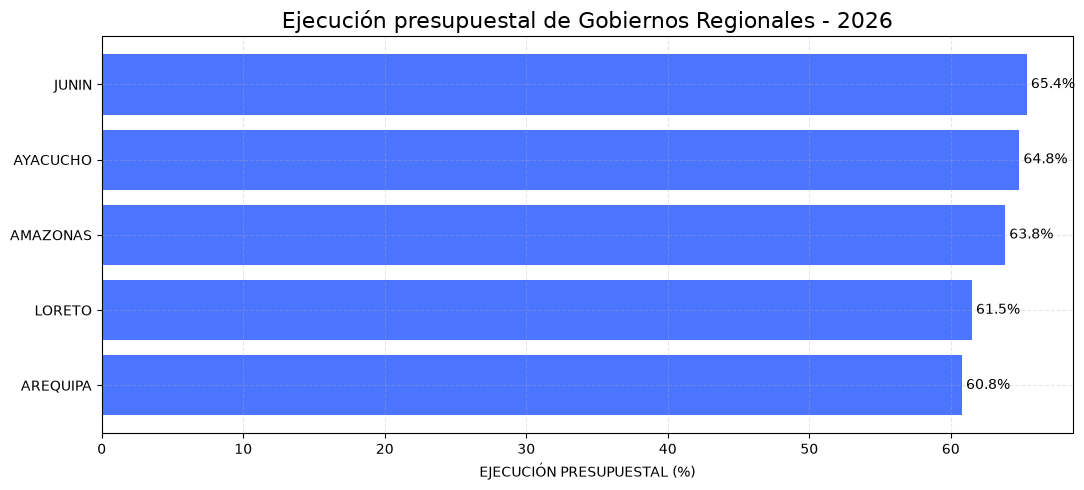

In [19]:
top_10 = regional.head(5).copy()

fig, ax = plt.subplots(figsize=(11,5))

ax.barh(top_10['DEPARTAMENTO_EJECUTORA_NOMBRE'],
        top_10['EJECUCION_%'], color='#4B75FF')

ax.invert_yaxis()

ax.set_xlabel('EJECUCIÓN PRESUPUESTAL (%)')
ax.set_title('Ejecución presupuestal de Gobiernos Regionales - 2026', fontsize = 16)
ax.grid(True, alpha=0.3)

for i, valor in enumerate(top_10['EJECUCION_%']):
    ax.text(valor + 0.3,
            i,
            f'{valor:.1f}%',
            va='center')

plt.tight_layout()
plt.show()

fig.savefig(
    "ranking_gobiernos_regionales.png",
    dpi=300,
    bbox_inches="tight"
)


In [25]:
df_junin = proyectos_regionales[proyectos_regionales['DEPARTAMENTO_EJECUTORA_NOMBRE'] == 'JUNIN']

In [26]:
tipo_gastos = df_junin.groupby(['DEPARTAMENTO_EJECUTORA_NOMBRE','ANO_EJE', 'FUNCION_NOMBRE'])[['MONTO_PIA',"MONTO_PIM", "MONTO_DEVENGADO"]].sum().reset_index()

tipo_gastos['EJECUCION_%'] = (tipo_gastos['MONTO_DEVENGADO'] / tipo_gastos['MONTO_PIM'])  * 100

tipo_gastos = tipo_gastos.sort_values(by='MONTO_DEVENGADO', ascending=False)
tipo_gastos.to_csv('tipo_gastos_junin.csv', index=False)
tipo_gastos

,DEPARTAMENTO_EJECUTORA_NOMBRE,ANO_EJE,FUNCION_NOMBRE,MONTO_PIA,MONTO_PIM,MONTO_DEVENGADO,EJECUCION_%
4,JUNIN,2026,EDUCACION,376244594,365085137,2.744500e+08,75.174239
13,JUNIN,2026,TRANSPORTE,273364462,266856234,1.813802e+08,67.969273
11,JUNIN,2026,SALUD,186056903,148895312,8.043522e+07,54.021323
0,JUNIN,2026,AGROPECUARIA,18479604,120004114,6.769379e+07,56.409557
12,JUNIN,2026,SANEAMIENTO,19993268,38517059,2.842661e+07,73.802662
9,JUNIN,2026,"PLANEAMIENTO, GESTION Y RESERVA DE CONTINGENCIA",21335410,56405158,1.677182e+07,29.734551
7,JUNIN,2026,ORDEN PUBLICO Y SEGURIDAD,21202351,13281421,1.061815e+07,79.947415
10,JUNIN,2026,PROTECCION SOCIAL,6000000,6796062,5.698628e+06,83.851919
15,JUNIN,2026,VIVIENDA Y DESARROLLO URBANO,12286729,7942535,4.158278e+06,52.354539
3,JUNIN,2026,CULTURA Y DEPORTE,0,3398554,3.398554e+06,99.999987


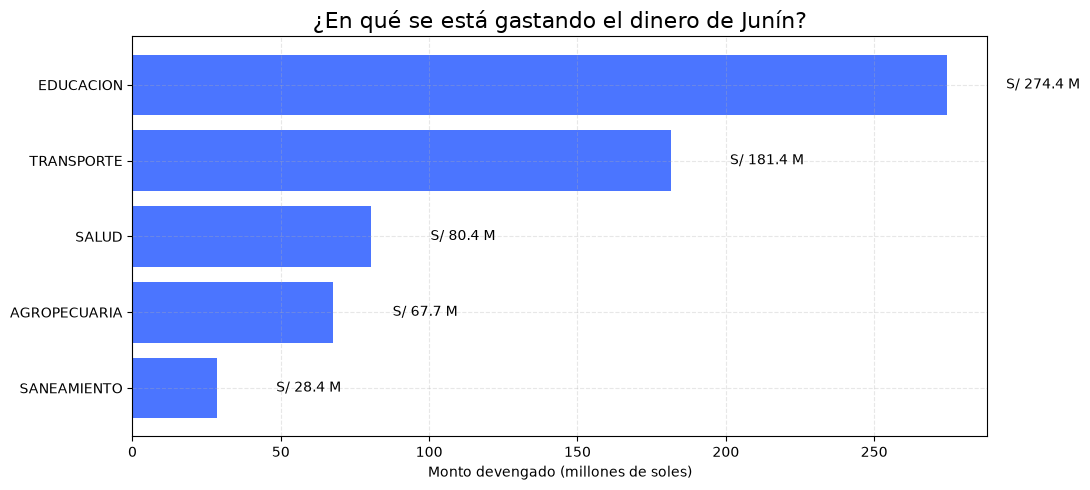

In [27]:
top_5 = tipo_gastos.head(5).copy()
top_5["DEVENGADO_M"] = top_5["MONTO_DEVENGADO"] / 1_000_000
top_5["PIM_M"] = top_5["MONTO_PIM"] / 1_000_000
top_5['RESTO'] = top_5['PIM_M'] - top_5['DEVENGADO_M']
top_5.to_csv('tipo_gastos_junin.csv', index=False)

fig, ax = plt.subplots(figsize=(11,5))

ax.barh(top_5['FUNCION_NOMBRE'],
        top_5['DEVENGADO_M'], color='#4B75FF')

ax.invert_yaxis()

ax.set_xlabel('Monto devengado (millones de soles)')
ax.set_title('¿En qué se está gastando el dinero de Junín?', fontsize = 16)
ax.grid(True, alpha=0.3)

for i, valor in enumerate(top_5["DEVENGADO_M"]):
    ax.text(
        valor + 20,
        i,
        f"S/ {valor:,.1f} M",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()